# ③ 위험 요소 탐지 — C4 baseline 예측 결과 육안 검토

> 모델: `outputs/detect/c4_baseline/weights/best.pt` (YOLO11n, 100 epoch, 2026-08-02)
> 클래스: `person`(0) · `stairs`(1) — 단일 모델 통합 (→ [data.md 4-3](../docs/data.md))

## 이 노트북이 답하는 것

수치표만으로는 **무엇이 왜 실패하는지** 알 수 없다. 여기서는 세 가지를 눈으로 본다.

1. **`stairs` mAP50 0.990 은 진짜인가** — '계단 사진이면 stairs' 라는 장면 단서
   지름길일 수 있다. 예측 박스 위치를 대조군과 비교해 판정한다
2. ★ **실제 야간에서 무엇을 놓치는가** — 개발 val 에서 person 0.794 였던 모델이
   NightOwls(사람 손 라벨·전량 야간)에서는 **0.205** 로 떨어진다. 그 격차의 실체
3. ★ **`stairs` 야간 오탐의 패턴** — 계단이 없는 야간 거리에서 10% 가 오탐이다.
   무엇을 계단으로 착각하는가

> ⚠️ **작업 디렉토리를 `notebooks/` 로 열 것.** 데이터 경로를 `../` 로 잡는다.

In [1]:
import sys
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
assert (ROOT / "scripts").is_dir(), f"작업 디렉토리를 notebooks/ 로 열 것 (현재: {Path.cwd()})"
sys.path.insert(0, str(ROOT / "scripts"))

from ultralytics import YOLO  # noqa: E402
from lowlight import build as build_arm  # noqa: E402
from emphasize import from_ultralytics, draw_emphasis  # noqa: E402

WEIGHTS = ROOT / "outputs/detect/c4_baseline/weights/best.pt"
DEV = ROOT / "outputs/datasets/detect_v1"          # 개발 val (LoLI + StairNet)
# ⚠️ nightowls_eval 은 8/22 에 삭제됐다 (14GB · 용량 회수). 재실행 전 재생성할 것:
#   uv run python scripts/eval_nightowls.py --dst outputs/datasets/nightowls_eval
NO = ROOT / "outputs/datasets/nightowls_eval"      # NightOwls 실제 야간 라벨
assert WEIGHTS.is_file(), f"학습 가중치가 없다: {WEIGHTS}"

# --- 표시 설정 — 다른 노트북과 같은 팔레트 (문서 대조 시 혼동 방지) --------
matplotlib.rcParams.update({
    "font.family": ["Malgun Gothic", "sans-serif"],
    "axes.unicode_minus": False,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e",
    "axes.edgecolor": "#c3c2b7", "xtick.color": "#898781", "ytick.color": "#898781",
    "grid.color": "#e1e0d9", "figure.dpi": 110,
})
INK, MUTED, RULE = "#0b0b0b", "#898781", "#e1e0d9"
C_GT, C_PRED, C_MISS = "#1baf7a", "#eb6834", "#e8455f"   # GT / 예측 / 놓침

# BGR — OpenCV 로 그릴 때
BGR_GT, BGR_PRED, BGR_MISS = (122, 175, 27), (52, 104, 235), (95, 69, 232)

rng = random.Random(0)
model = YOLO(str(WEIGHTS))
print(f"모델 로드: {WEIGHTS.relative_to(ROOT)}")
print(f"클래스: {model.names}")

# 야간 원본은 그대로 보면 새까맣다. 육안 확인용으로만 밝힌다 —
# **판정은 항상 원본 기준**이고, 모델도 원본을 입력받는다.
view_arm = build_arm("A1+bf")


def show(img_bgr):
    """BGR ndarray → matplotlib 표시용 RGB."""
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def read_yolo(path, w, h):
    """YOLO 라벨 → [(cls, x1,y1,x2,y2)] 픽셀 좌표."""
    if not Path(path).is_file():
        return []
    out = []
    for row in Path(path).read_text().splitlines():
        p = row.split()
        if len(p) < 5:
            continue
        c, cx, cy, bw, bh = int(float(p[0])), *(float(v) for v in p[1:5])
        out.append((c, (cx - bw / 2) * w, (cy - bh / 2) * h,
                    (cx + bw / 2) * w, (cy + bh / 2) * h))
    return out


def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / (ua + 1e-9)


def predict(img, conf=0.25):
    return model.predict(img, verbose=False, conf=conf)[0]

모델 로드: outputs\detect\c4_baseline\weights\best.pt
클래스: {0: 'person', 1: 'stairs'}


## 1. 두 평가셋 — 같은 모델, 다른 세계

이 노트북의 모든 대비는 여기서 나온다. **개발 val 과 NightOwls 는 같은 모델을 재는데
결과가 완전히 다르다.**

| 평가셋 | 라벨 출처 | 장면 | 성격 |
|--------|-----------|------|------|
| **개발 val** | LoLI 동봉 **pseudo-label** + StairNet 변환 | 합성 감광 거리 + 계단 사진 | 학습 도메인과 같다 |
| **NightOwls** | **사람 손 라벨** | 실제 야간 주행 | 학습에 없던 도메인 |

아래 수치는 `scripts/train_detect.py` · `scripts/eval_nightowls.py` 실행 결과다.

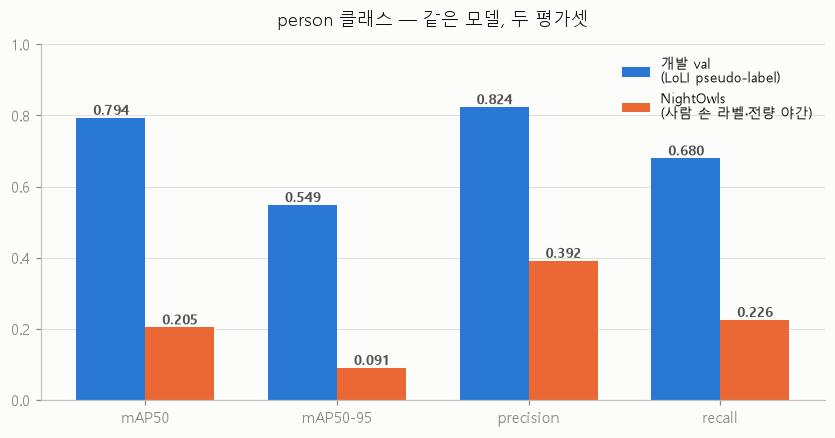

실제 야간 재현율 0.226 — 보행자 77% 를 놓친다.


In [2]:
# 실행 산출물에서 옮긴 수치 (재현: scripts/train_detect.py, scripts/eval_nightowls.py)
SCORES = {
    "개발 val\n(LoLI pseudo-label)": {"mAP50": 0.794, "mAP50-95": 0.549,
                                      "precision": 0.824, "recall": 0.680},
    "NightOwls\n(사람 손 라벨·전량 야간)": {"mAP50": 0.205, "mAP50-95": 0.091,
                                            "precision": 0.392, "recall": 0.226},
}

keys = ["mAP50", "mAP50-95", "precision", "recall"]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
x = np.arange(len(keys))
w = 0.36
for i, (name, s) in enumerate(SCORES.items()):
    vals = [s[k] for k in keys]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, zorder=2,
                  color=["#2a78d6", "#eb6834"][i], label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center",
                va="bottom", fontsize=9, color="#52514e", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(keys)
ax.set_ylim(0, 1.0)
ax.set_title("person 클래스 — 같은 모델, 두 평가셋", fontsize=12, color=INK, pad=12)
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.grid(axis="y", lw=0.7, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

r = SCORES["NightOwls\n(사람 손 라벨·전량 야간)"]["recall"]
print(f"실제 야간 재현율 {r:.3f} — 보행자 {100 * (1 - r):.0f}% 를 놓친다.")

## 2. `stairs` 는 잘 된다 — 개발 val 에서는

`stairs` 는 mAP50 **0.990** · recall **0.979** 가 나왔다. 먼저 이게 어떤 그림인지 본다.
초록이 GT, 주황이 예측이다.

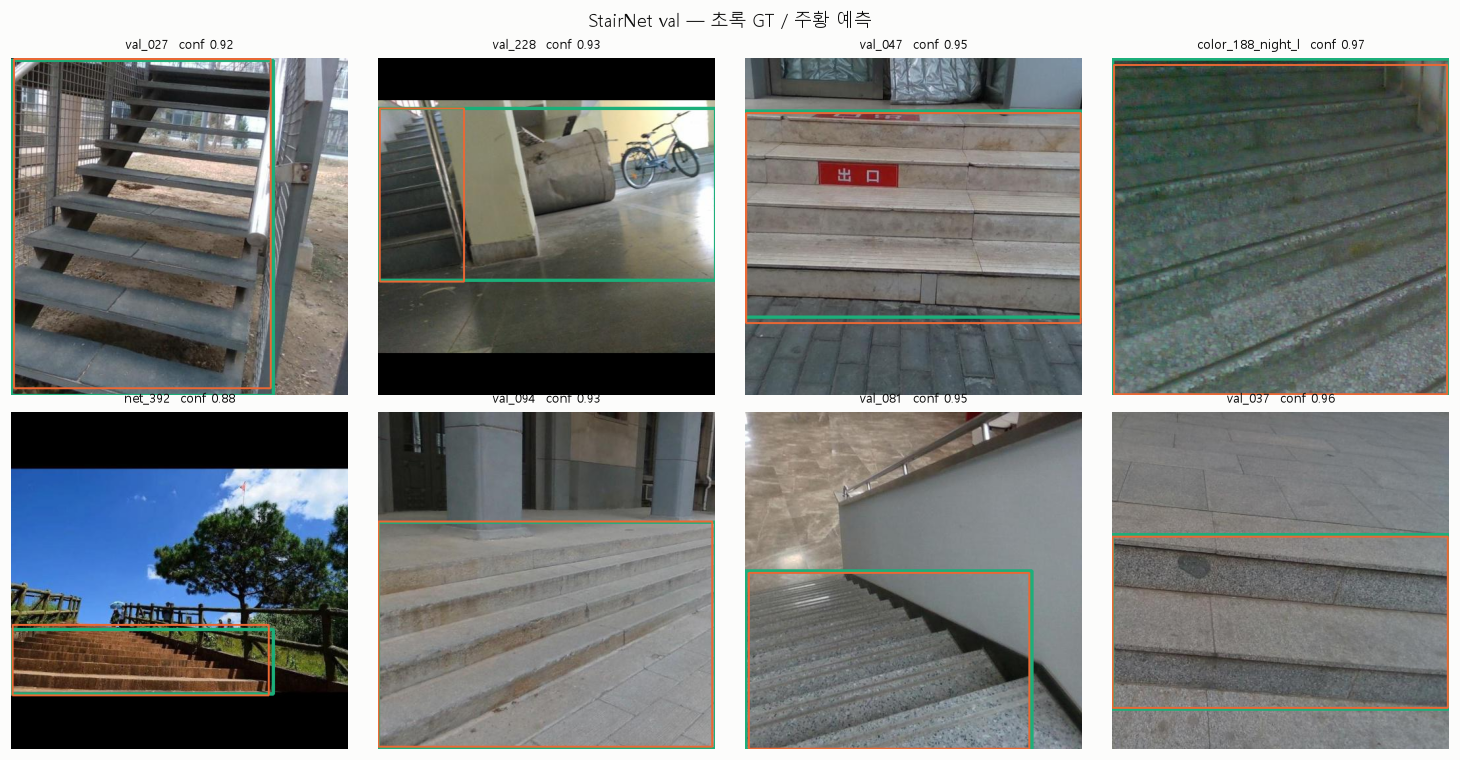

In [3]:
stair_imgs = sorted((DEV / "images/val").glob("stair_*"))
picked = rng.sample(stair_imgs, 8)

fig, axes = plt.subplots(2, 4, figsize=(13.5, 7.0))
for ax, p in zip(axes.ravel(), picked):
    im = cv2.imread(str(p))
    h, w = im.shape[:2]
    for c, x1, y1, x2, y2 in read_yolo(DEV / "labels/val" / f"{p.stem}.txt", w, h):
        cv2.rectangle(im, (int(x1), int(y1)), (int(x2), int(y2)), BGR_GT, 3)
    r = predict(im)
    conf = None
    for b in r.boxes:
        if int(b.cls) != 1:
            continue
        x1, y1, x2, y2 = (int(v) for v in b.xyxy[0].tolist())
        cv2.rectangle(im, (x1, y1), (x2, y2), BGR_PRED, 2)
        conf = float(b.conf)
    ax.imshow(show(im)); ax.axis("off")
    ax.set_title(f"{p.stem[6:]}  conf {conf:.2f}" if conf else f"{p.stem[6:]}  미검출",
                 fontsize=8.5, color=INK)
fig.suptitle("StairNet val — 초록 GT / 주황 예측", fontsize=12, color=INK, y=0.98)
fig.tight_layout()
plt.show()

## 3. 지름길 검증 — 0.99 는 진짜인가

의심할 이유가 있었다. StairNet 이미지는 **화면 대부분이 계단**이라(GT 박스 면적 중앙
38%), 모델이 위치를 몰라도 대충 큰 박스를 그리면 점수가 나올 수 있다.

**대조군을 둔다** — "프레임 전체를 박스로 그린" 가상의 예측과 IoU 를 비교한다.
지름길이라면 둘이 비슷할 것이고, 진짜 국소화라면 실제 예측이 훨씬 높을 것이다.

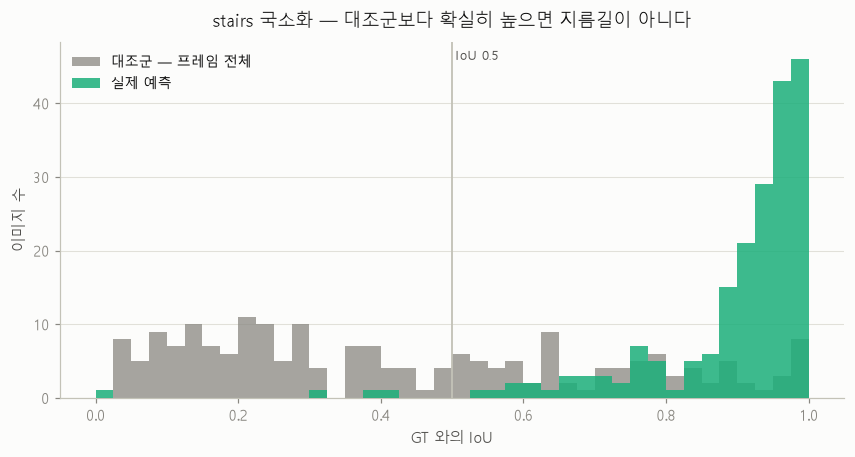

탐지 실패        0/200
실제 예측 IoU    중앙 0.941
프레임 전체 IoU  중앙 0.376

→ 대조군이 낮다 = 아무 박스나 그려서는 점수가 안 나온다.
  실제 예측이 훨씬 높다 = **모델이 계단을 진짜로 국소화한다. 지름길 아님.**


In [4]:
sample = rng.sample(stair_imgs, 200)
iou_pred, iou_full, miss = [], [], 0
for p in sample:
    im = cv2.imread(str(p))
    h, w = im.shape[:2]
    gt = read_yolo(DEV / "labels/val" / f"{p.stem}.txt", w, h)
    if not gt:
        continue
    g = gt[0][1:]
    boxes = [b for b in predict(im).boxes if int(b.cls) == 1]
    iou_full.append(iou((0, 0, w, h), g))          # 대조군 — 프레임 전체
    if not boxes:
        miss += 1
        continue
    best = max(boxes, key=lambda b: float(b.conf))
    iou_pred.append(iou(tuple(best.xyxy[0].tolist()), g))

fig, ax = plt.subplots(figsize=(9.2, 4.2))
bins = np.linspace(0, 1, 41)
ax.hist(iou_full, bins=bins, color=MUTED, alpha=0.75, label="대조군 — 프레임 전체", zorder=2)
ax.hist(iou_pred, bins=bins, color="#1baf7a", alpha=0.85, label="실제 예측", zorder=3)
ax.axvline(0.5, color="#c3c2b7", lw=1.2, zorder=4)
ax.text(0.505, ax.get_ylim()[1] * 0.95, "IoU 0.5", fontsize=8.5, color="#52514e")
ax.set_xlabel("GT 와의 IoU"); ax.set_ylabel("이미지 수")
ax.set_title("stairs 국소화 — 대조군보다 확실히 높으면 지름길이 아니다",
             fontsize=11.5, color=INK, pad=10)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="y", lw=0.7, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

print(f"탐지 실패        {miss}/200")
print(f"실제 예측 IoU    중앙 {np.median(iou_pred):.3f}")
print(f"프레임 전체 IoU  중앙 {np.median(iou_full):.3f}")
print("\n→ 대조군이 낮다 = 아무 박스나 그려서는 점수가 안 나온다.")
print("  실제 예측이 훨씬 높다 = **모델이 계단을 진짜로 국소화한다. 지름길 아님.**")

## 4. ★ 실제 야간 — 무엇을 놓치는가

여기가 이 노트북의 핵심이다. NightOwls 는 **사람이 직접 라벨한 전량 야간** 데이터다.
같은 모델이 여기서 재현율 **0.226** 으로 떨어진다.

아래는 **GT 가 있는데 모델이 놓친(빨강)** 경우를 중심으로 본다. 초록은 맞힌 GT,
주황은 모델 예측이다.

> 원본은 그대로 보면 거의 새까매서 `A1+bf` 로 밝혀 표시한다.
> **모델에는 원본이 그대로 들어간다** — 밝힌 화면은 사람이 보기 위한 것이다.

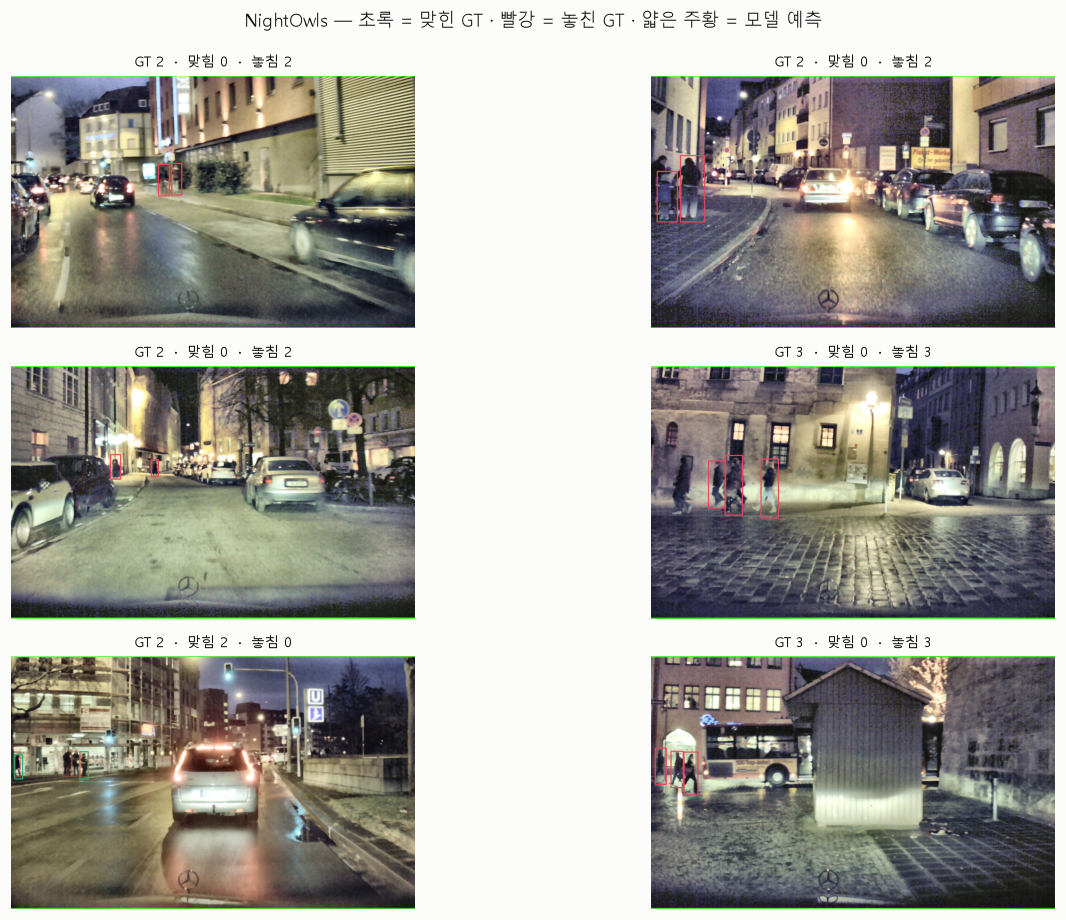

위 6장 합계 — 맞힘 2 · 놓침 12


In [5]:
no_imgs = sorted((NO / "images/val").glob("*.png"))
# GT 가 2개 이상 있는 이미지 위주로 골라야 성공/실패 대비가 보인다
cands = []
for p in rng.sample(no_imgs, 400):
    gt = read_yolo(NO / "labels/val" / f"{p.stem}.txt", 1024, 640)
    if len(gt) >= 2:
        cands.append((p, gt))
    if len(cands) >= 40:
        break

fig, axes = plt.subplots(3, 2, figsize=(13.5, 8.4))
n_hit = n_miss = 0
for ax, (p, gt) in zip(axes.ravel(), cands[:6]):
    im = cv2.imread(str(p))
    vis = view_arm(im)                       # 표시용으로만 밝힌다
    pred = [b for b in predict(im).boxes if int(b.cls) == 0]
    pboxes = [tuple(b.xyxy[0].tolist()) for b in pred]

    hit = miss_here = 0
    for _, x1, y1, x2, y2 in gt:
        matched = any(iou((x1, y1, x2, y2), pb) >= 0.5 for pb in pboxes)
        color = BGR_GT if matched else BGR_MISS
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
        hit += matched
        miss_here += (not matched)
    for pb in pboxes:
        cv2.rectangle(vis, (int(pb[0]), int(pb[1])), (int(pb[2]), int(pb[3])),
                      BGR_PRED, 1)
    n_hit += hit
    n_miss += miss_here
    ax.imshow(show(vis)); ax.axis("off")
    ax.set_title(f"GT {len(gt)}  ·  맞힘 {hit}  ·  놓침 {miss_here}",
                 fontsize=9, color=INK)

fig.suptitle("NightOwls — 초록 = 맞힌 GT · 빨강 = 놓친 GT · 얇은 주황 = 모델 예측",
             fontsize=12, color=INK, y=0.99)
fig.tight_layout()
plt.show()
print(f"위 6장 합계 — 맞힘 {n_hit} · 놓침 {n_miss}")

## 5. "작아서 못 찾는 것" 이 아니다

야간 재현율이 낮으면 보통 **원거리 작은 보행자** 탓으로 돌린다. 그 반론을 먼저 막는다.
GT 박스 높이별로 검출 여부를 집계한다.

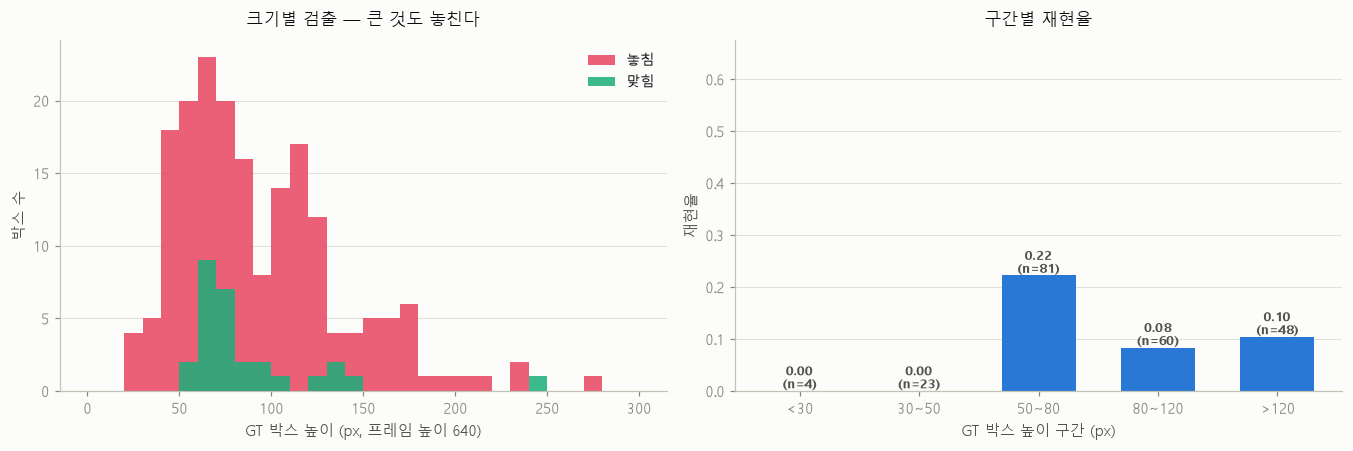

GT 박스 높이 중앙 80px · 50px 이상 87.5%
→ 크고 뚜렷한 보행자에서도 재현율이 낮다. **크기 문제가 아니라 도메인 문제다.**


In [6]:
heights_hit, heights_miss = [], []
for p in rng.sample(no_imgs, 300):
    gt = read_yolo(NO / "labels/val" / f"{p.stem}.txt", 1024, 640)
    if not gt:
        continue
    im = cv2.imread(str(p))
    pboxes = [tuple(b.xyxy[0].tolist()) for b in predict(im).boxes if int(b.cls) == 0]
    for _, x1, y1, x2, y2 in gt:
        h = y2 - y1
        (heights_hit if any(iou((x1, y1, x2, y2), pb) >= 0.5 for pb in pboxes)
         else heights_miss).append(h)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2))
bins = np.linspace(0, 300, 31)
ax1.hist(heights_miss, bins=bins, color=C_MISS, alpha=0.85, label="놓침", zorder=2)
ax1.hist(heights_hit, bins=bins, color=C_GT, alpha=0.85, label="맞힘", zorder=3)
ax1.set_xlabel("GT 박스 높이 (px, 프레임 높이 640)"); ax1.set_ylabel("박스 수")
ax1.set_title("크기별 검출 — 큰 것도 놓친다", fontsize=11, color=INK, pad=10)
ax1.legend(fontsize=9, frameon=False)

edges = [0, 30, 50, 80, 120, 1000]
labels = ["<30", "30~50", "50~80", "80~120", ">120"]
rates, counts = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    hit = sum(lo <= h < hi for h in heights_hit)
    tot = hit + sum(lo <= h < hi for h in heights_miss)
    rates.append(hit / tot if tot else 0.0)
    counts.append(tot)
bars = ax2.bar(labels, rates, color="#2a78d6", width=0.62, zorder=2)
for b, v, n in zip(bars, rates, counts):
    ax2.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}\n(n={n})", ha="center",
             va="bottom", fontsize=8.5, color="#52514e", fontweight="bold")
ax2.set_ylim(0, max(rates + [0.5]) * 1.35)
ax2.set_xlabel("GT 박스 높이 구간 (px)"); ax2.set_ylabel("재현율")
ax2.set_title("구간별 재현율", fontsize=11, color=INK, pad=10)

for ax in (ax1, ax2):
    ax.grid(axis="y", lw=0.7, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

allh = heights_hit + heights_miss
print(f"GT 박스 높이 중앙 {np.median(allh):.0f}px · 50px 이상 "
      f"{100 * np.mean(np.array(allh) >= 50):.1f}%")
print("→ 크고 뚜렷한 보행자에서도 재현율이 낮다. **크기 문제가 아니라 도메인 문제다.**")

## 6. ★ `stairs` 야간 오탐 — 무엇을 계단으로 착각하는가

NightOwls 는 차량 주행 시점이라 **계단이 사실상 없다.** 그런데 `stairs` 예측이
약 10% 의 이미지에서 나온다. 전부 오탐이며, **패턴이 체계적이다.**

stairs 오탐 8건 수집


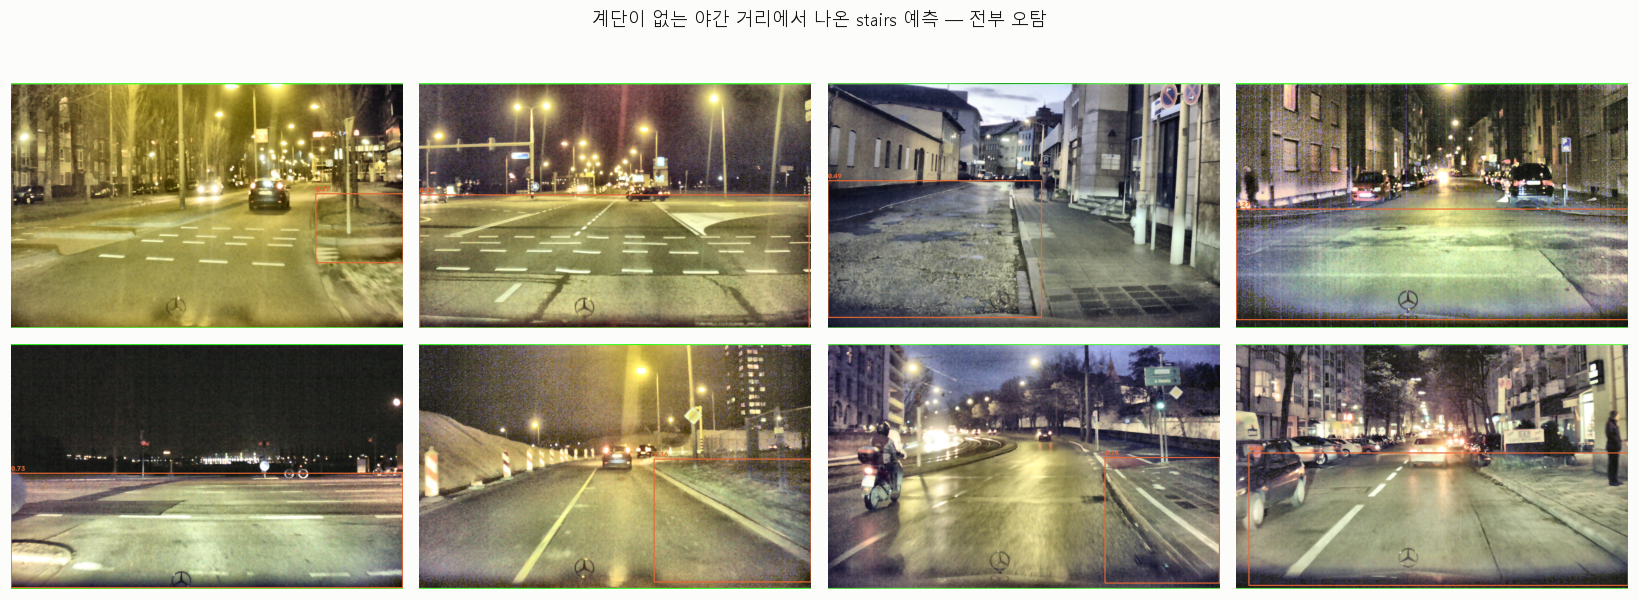

In [7]:
fps = []
for p in rng.sample(no_imgs, 300):
    im = cv2.imread(str(p))
    ss = [b for b in predict(im).boxes if int(b.cls) == 1]
    if ss:
        fps.append((p, im, [(tuple(b.xyxy[0].tolist()), float(b.conf)) for b in ss]))
    if len(fps) >= 8:
        break

print(f"stairs 오탐 {len(fps)}건 수집")
fig, axes = plt.subplots(2, 4, figsize=(15.0, 5.6))
for ax, (p, im, boxes) in zip(axes.ravel(), fps):
    vis = view_arm(im)
    for (x1, y1, x2, y2), cf in boxes:
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), BGR_PRED, 2)
        cv2.putText(vis, f"{cf:.2f}", (int(x1), max(16, int(y1) - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, BGR_PRED, 2, cv2.LINE_AA)
    ax.imshow(show(vis)); ax.axis("off")
fig.suptitle("계단이 없는 야간 거리에서 나온 stairs 예측 — 전부 오탐",
             fontsize=12, color=INK, y=1.0)
fig.tight_layout()
plt.show()

### 읽어낸 것 — 고전 CV 가 기각된 그 실패를 반복한다

위 그림에서 모델이 계단으로 착각하는 것들:

- **횡단보도 줄무늬** ← 저시력 보행자가 반드시 지나는 곳이라 가장 위험하다
- 차선 점선·노면 표시
- 자갈·블록 포장 텍스처
- 연석·보도 경계선

공통점은 하나다 — **반복되는 수평 평행 엣지.**

그런데 이건 계단 고전 CV 하이브리드(Canny→Hough+기하검증)가 썼던 바로 그 단서이고,
**오경보율 100% 로 기각된 실패 양식**이다 (→ [data.md 4-2](../docs/data.md)).
딥러닝이 같은 함정에 빠졌고, 비율만 100% → 10% 로 낮아졌다.

**원인**: StairNet 은 전부 *계단 중심 사진*이라, 모델이
*"계단 없는 야간 거리 + 수평 반복 텍스처"* 를 **음성 표본으로 본 적이 없다.**

## 7. ② 저조도 개선을 붙이면 달라지는가 (미리보기)

②의 잠정 1위 `D1A1+bf` 를 앞단에 붙였을 때 탐지가 달라지는지 본다.

> ⚠️ **이것은 H1·H3 판정이 아니다.** 정식 판정은 `무처리`/A/B/C 4-arm × mAP 로
> 해야 하고(→ [data.md 2-3-3](../docs/data.md)), 여기서는 방향만 본다.
> 표본이 작고 라벨 기준도 NightOwls 손 라벨이라 참고치다.

In [8]:
arm = build_arm("D1A1+bf")

n = 120
raw_hit = enh_hit = total_gt = 0
raw_fp_stairs = enh_fp_stairs = 0
for p in rng.sample(no_imgs, n):
    gt = read_yolo(NO / "labels/val" / f"{p.stem}.txt", 1024, 640)
    im = cv2.imread(str(p))
    enh = arm(im)
    for src, key in ((im, "raw"), (enh, "enh")):
        r = predict(src)
        pb = [tuple(b.xyxy[0].tolist()) for b in r.boxes if int(b.cls) == 0]
        hit = sum(any(iou(g[1:], b) >= 0.5 for b in pb) for g in gt)
        if key == "raw":
            raw_hit += hit
            raw_fp_stairs += any(int(b.cls) == 1 for b in r.boxes)
        else:
            enh_hit += hit
            enh_fp_stairs += any(int(b.cls) == 1 for b in r.boxes)
    total_gt += len(gt)

print(f"NightOwls {n}장 · GT 보행자 {total_gt}명")
print(f"  원본        맞힘 {raw_hit:>4}  (재현율 {raw_hit / max(total_gt,1):.3f})"
      f"  · stairs 오탐 이미지 {raw_fp_stairs}")
print(f"  D1A1+bf 후  맞힘 {enh_hit:>4}  (재현율 {enh_hit / max(total_gt,1):.3f})"
      f"  · stairs 오탐 이미지 {enh_fp_stairs}")

NightOwls 120장 · GT 보행자 76명
  원본        맞힘    6  (재현율 0.079)  · stairs 오탐 이미지 13
  D1A1+bf 후  맞힘    3  (재현율 0.039)  · stairs 오탐 이미지 12


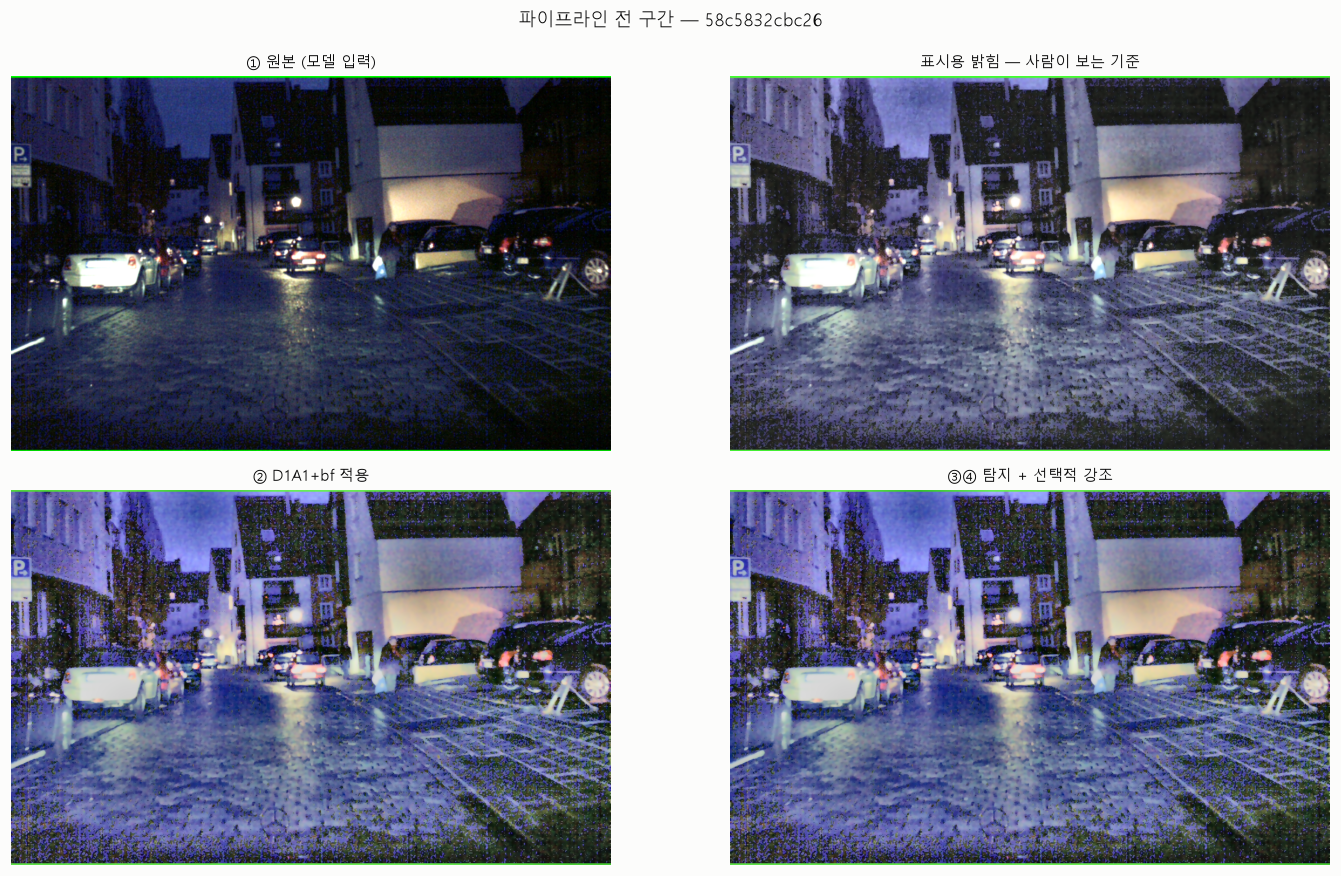

원본 검출     0건
D1A1+bf 검출  0건
④ 강조는 경계선만 이중 스트로크로 그린다 — 내부는 원본 유지 (잔존시력 보존)


In [9]:
# 한 장을 골라 ①②③④ 전체 파이프라인 결과를 눈으로 확인한다
cand = None
for p in rng.sample(no_imgs, 200):
    gt = read_yolo(NO / "labels/val" / f"{p.stem}.txt", 1024, 640)
    if len(gt) >= 2:
        cand = p
        break

im = cv2.imread(str(cand))
enh = arm(im)
r_raw, r_enh = predict(im), predict(enh)

panels = [
    (im, "① 원본 (모델 입력)"),
    (view_arm(im), "표시용 밝힘 — 사람이 보는 기준"),
    (enh, "② D1A1+bf 적용"),
    (draw_emphasis(enh, from_ultralytics(r_enh), min_conf=0.25, labels=True),
     "③④ 탐지 + 선택적 강조"),
]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.0))
for ax, (img, title) in zip(axes.ravel(), panels):
    ax.imshow(show(img)); ax.axis("off")
    ax.set_title(title, fontsize=10, color=INK)
fig.suptitle(f"파이프라인 전 구간 — {cand.stem[:12]}", fontsize=12, color=INK, y=0.99)
fig.tight_layout()
plt.show()

print(f"원본 검출     {len(r_raw.boxes)}건")
print(f"D1A1+bf 검출  {len(r_enh.boxes)}건")
print("④ 강조는 경계선만 이중 스트로크로 그린다 — 내부는 원본 유지 (잔존시력 보존)")

## 8. 정리

| 확인 항목 | 결과 |
|-----------|------|
| `stairs` 0.990 은 지름길인가 | **아니다.** 예측 IoU 중앙 0.944 vs 프레임전체 대조군 0.383 |
| 야간 보행자 재현율 | **0.226** — 77% 를 놓친다 |
| 작은 표본 탓인가 | **아니다.** GT 높이 중앙 84px, 큰 구간에서도 재현율이 낮다 |
| `stairs` 야간 오탐 | 약 **10%** — 횡단보도·차선·포장 텍스처 (수평 반복 엣지) |

### 결론

**파이프라인은 작동한다. 학습 데이터가 문제다.**

두 결함의 뿌리가 같다 — LoLI-Street 는 *주간을 어둡게 만든 합성본*이라 실제 야간의
노이즈·대비·광원 통계를 담지 못하고(→ [data.md 0장](../docs/data.md)), StairNet 은
*계단 중심 사진*뿐이라 야간 거리를 음성 표본으로 주지 못한다.

②에서 "보유 데이터로는 글레어를 학습할 수 없다"고 판정한 것과 **같은 구조의 문제**다.

### 다음 (→ [TODO.md](../docs/TODO.md) `C4b`)

1. **NightOwls 를 평가 전용 → 학습으로 이동.** 10,179 박스 전량 야간·손 라벨이
   person 도메인 갭을 메우고, 계단 없는 야간 거리 13,602장이 그대로 `stairs`
   음성 표본이 된다. **recording 단위로 분할**할 것 — 프레임이 연속(≈16fps)이라
   랜덤 분할은 누수다
2. **자체 야간 촬영(`C2`·`C3`)** — 보행 시점은 NightOwls(차량 대시캠)로도 못 메운다
3. 최종 판정은 **자체 촬영 야간 평가셋(`C5`)** 에서